# CS4305 Artificial Intelligence — Lab 3
## Prolog: Programming in Logic

**What you will learn today**
1. Write **facts** and **rules** in Prolog
2. Ask **questions (queries)** and get answers
3. See how Prolog finds answers by **matching** and **backtracking**
4. Use **recursion**, **lists** and **arithmetic**
5. Build a tiny **expert system** in Prolog

**How to use this notebook**
- 📊 **Visual explanation** cells already show a picture. Look at the picture first, then read the code.
- 💻 **Code** cells: click inside and press **Shift + Enter** to run them, from top to bottom.
- 📝 **Lab tasks** are at the end.

In [ ]:
#@title ⚙️ Diagram tools (only needed if you want to redraw the pictures)
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle

PURPLE, ORANGE, TEAL, ROSE, DARK = "#5B2A86", "#FF9F1C", "#1FA898", "#D1495B", "#1A1333"
LIGHT, GREY, WHITE = "#F3EEFA", "#A9A3B8", "#FFFFFF"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 12})

def tree_layout(children, root, gap=1.0):
    """Tidy layout for a tree given as {parent: [children]}."""
    pos, nxt = {}, [0.0]
    def walk(n, d):
        kids = children.get(n, [])
        if not kids:
            pos[n] = (nxt[0], -d); nxt[0] += gap
        else:
            for k in kids: walk(k, d + 1)
            xs = [pos[k][0] for k in kids]
            pos[n] = ((min(xs) + max(xs)) / 2, -d)
    walk(root, 0)
    return pos

def draw_graph(ax, pos, edges, directed=False, weights=None, colors=None, path=None, r=0.28,
               fs=13, label_below=False, badges=None, badge_color=ORANGE, edge_fs=11, names=None):
    """Draw nodes (circles) and edges. path = list of nodes to highlight in orange."""
    colors = colors or {}
    on_path = set()
    if path:
        for a, b in zip(path, path[1:]): on_path |= {(a, b), (b, a)}
    for i, (a, b) in enumerate(edges):
        (x1, y1), (x2, y2) = pos[a], pos[b]
        L = math.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
        s, e = (x1 + ux * r, y1 + uy * r), (x2 - ux * r, y2 - uy * r)
        hi = (a, b) in on_path
        ax.annotate("", xy=e, xytext=s, arrowprops=dict(arrowstyle="-|>" if directed else "-",
                    color=ORANGE if hi else GREY, lw=4 if hi else 1.8, shrinkA=0, shrinkB=0,
                    mutation_scale=18), zorder=1)
        if weights:
            w = weights[i]
            ax.text((x1 + x2) / 2, (y1 + y2) / 2, str(w), ha="center", va="center", fontsize=edge_fs,
                    color=DARK, fontweight="bold", zorder=4,
                    bbox=dict(boxstyle="round,pad=0.2", fc=WHITE, ec="none"))
    for n, (x, y) in pos.items():
        c = colors.get(n, PURPLE)
        ax.add_patch(Circle((x, y), r, fc=c, ec=WHITE, lw=2, zorder=3))
        text = (names or {}).get(n, n)
        if label_below:
            ax.text(x, y - r - 0.06, text, ha="center", va="top", fontsize=fs, color=DARK, fontweight="bold", zorder=5)
        else:
            ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=WHITE if c not in (ORANGE, LIGHT, WHITE) else DARK,
                    fontweight="bold", zorder=5)
    if badges:
        for n, t in badges.items():
            x, y = pos[n]
            ax.add_patch(Circle((x + r * 0.95, y + r * 0.95), r * 0.55, fc=badge_color, ec=WHITE, lw=1.5, zorder=6))
            ax.text(x + r * 0.95, y + r * 0.95, str(t), ha="center", va="center", fontsize=fs - 3,
                    color=DARK, fontweight="bold", zorder=7)
    xs = [p[0] for p in pos.values()]; ys = [p[1] for p in pos.values()]
    m = r * 2.2
    ax.set_xlim(min(xs) - m, max(xs) + m); ax.set_ylim(min(ys) - m - (0.35 if label_below else 0), max(ys) + m)
    ax.set_aspect("equal"); ax.axis("off")

def box(ax, x, y, w, h, text, fc=PURPLE, tc=WHITE, fs=13, bold=True, ec=None, round_=True):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.08" if round_ else "square,pad=0",
                                fc=fc, ec=ec or fc, lw=1.5, zorder=2))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fs, color=tc,
            fontweight="bold" if bold else "normal", zorder=3)

def arrow(ax, x1, y1, x2, y2, color=DARK, lw=2, text=None, fs=11):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, shrinkA=0, shrinkB=0, mutation_scale=16))
    if text:
        ax.text((x1 + x2) / 2, (y1 + y2) / 2 + 0.12, text, ha="center", va="bottom", fontsize=fs, color=DARK)

def board(ax, x0, y0, state, size=0.9, title=None, highlight=None, fc=LIGHT):
    """Draw an 8-puzzle board. state = string like '123456780' (0 = blank)."""
    highlight = highlight or {}
    for i, ch in enumerate(state):
        r, c = divmod(i, 3)
        x, y = x0 + c * size, y0 - r * size
        blank = ch == "0"
        ax.add_patch(Rectangle((x, y), size, size, fc=WHITE if blank else highlight.get(ch, fc),
                               ec=DARK, lw=2, zorder=2))
        if not blank:
            ax.text(x + size / 2, y + size / 2, ch, ha="center", va="center", fontsize=20, fontweight="bold",
                    color=WHITE if highlight.get(ch) in (PURPLE, ROSE, TEAL) else DARK, zorder=3)
    if title:
        ax.text(x0 + 1.5 * size, y0 + size + 0.25, title, ha="center", va="bottom", fontsize=14, fontweight="bold", color=DARK)

def finish(fig, title=None):
    if title:
        fig.suptitle(title, fontsize=16, fontweight="bold", color=DARK)
    fig.tight_layout()


# ---- shared data for this lab's diagrams ----

print('Diagram tools ready')

---
## Part 0: Setting up Prolog in Colab
Colab runs Python, so first we install **SWI-Prolog** (a free Prolog system). Then we make a small helper `ask()` that sends our question to Prolog and prints every answer — just like typing at Prolog's `?-` prompt.

In [ ]:
# ===== Step 1: Install SWI-Prolog inside Colab (takes about 30 seconds, run once) =====
!apt-get install -y swi-prolog-nox > /dev/null 2>&1
!swipl --version

In [ ]:
# ===== Step 2: A helper so we can ask Prolog questions from Python =====
import subprocess

def ask(query, file):
    """Ask Prolog a question (like typing at the ?- prompt) and print ALL answers."""
    goal = f"""read_term_from_atom({query!r}, Q, [variable_names(B)]),
      ( B == [] -> ( call(Q) -> writeln(true) ; writeln(false) )
      ; findall(B, call(Q), L),
        ( L == [] -> writeln(false)
        ; forall(member(S, L), (forall(member(N=V, S), format("~w = ~w   ", [N, V])), nl)) ) )"""
    r = subprocess.run(["swipl", "-q", "-g", goal, "-t", "halt", file], capture_output=True, text=True)
    print(f"?- {query}.")
    print((r.stdout or r.stderr).strip(), "\n")

print("Helper ready!")

---
## Part 1: Facts — writing down what is true
A **fact** is a simple true statement. `parent(ahmed, bilal).` means *"Ahmed is a parent of Bilal"*.

**Remember:** names start with a **small letter**, and every fact ends with a **full stop (.)**

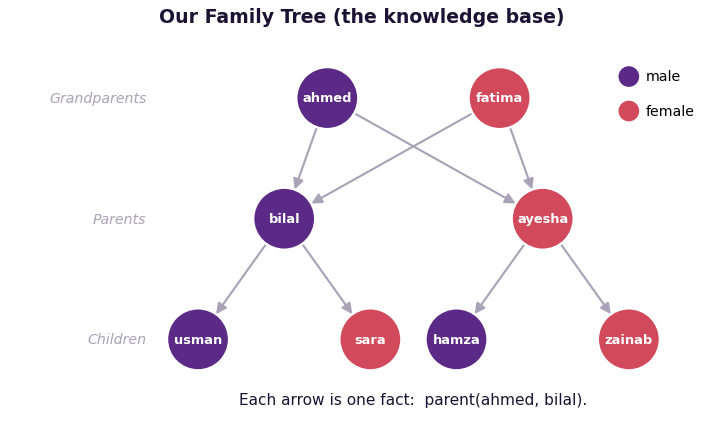

In [ ]:
#@title 📊 Visual explanation: the family tree we will describe
def fig_family_tree():
    children = {"top": ["ahmed", "fatima"]}
    pos = {"ahmed": (1.5, 2), "fatima": (3.5, 2), "bilal": (1, 0.6), "ayesha": (4, 0.6),
           "usman": (0, -0.8), "sara": (2, -0.8), "hamza": (3, -0.8), "zainab": (5, -0.8)}
    male = {"ahmed", "bilal", "usman", "hamza"}
    edges = [("ahmed", "bilal"), ("fatima", "bilal"), ("ahmed", "ayesha"), ("fatima", "ayesha"),
             ("bilal", "usman"), ("bilal", "sara"), ("ayesha", "hamza"), ("ayesha", "zainab")]
    fig, ax = plt.subplots(figsize=(11, 5.2))
    cols = {n: (PURPLE if n in male else ROSE) for n in pos}
    draw_graph(ax, pos, edges, directed=True, colors=cols, r=0.36, fs=11)
    ax.text(-0.6, 2, "Grandparents", fontsize=12, color=GREY, ha="right", va="center", style="italic")
    ax.text(-0.6, 0.6, "Parents", fontsize=12, color=GREY, ha="right", va="center", style="italic")
    ax.text(-0.6, -0.8, "Children", fontsize=12, color=GREY, ha="right", va="center", style="italic")
    ax.add_patch(Circle((5.0, 2.25), 0.12, fc=PURPLE)); ax.text(5.2, 2.25, "male", va="center", fontsize=12)
    ax.add_patch(Circle((5.0, 1.85), 0.12, fc=ROSE)); ax.text(5.2, 1.85, "female", va="center", fontsize=12)
    ax.text(2.5, -1.55, "Each arrow is one fact:  parent(ahmed, bilal).", ha="center", fontsize=13, color=DARK)
    ax.set_xlim(-2.2, 6); ax.set_ylim(-1.8, 2.6)
    finish(fig, "Our Family Tree (the knowledge base)")
    return fig

fig_family_tree()
plt.show()

In the picture, **every arrow is one `parent` fact**. Below, `%%writefile` saves our Prolog program into a file called `family.pl`. We also add some **rules** (Part 3).

In [ ]:
%%writefile family.pl
% ---------- FACTS: things that are simply true ----------
male(ahmed).    male(bilal).    male(usman).    male(hamza).
female(fatima). female(ayesha). female(sara).   female(zainab).

parent(ahmed, bilal).      % "Ahmed is a parent of Bilal"
parent(fatima, bilal).
parent(ahmed, ayesha).
parent(fatima, ayesha).
parent(bilal, usman).
parent(bilal, sara).
parent(ayesha, hamza).
parent(ayesha, zainab).

% ---------- RULES: new knowledge built from facts ----------
% read  ":-"  as  "IF",  and  ","  as  "AND"
father(X, Y)      :- parent(X, Y), male(X).
mother(X, Y)      :- parent(X, Y), female(X).
grandparent(X, Z) :- parent(X, Y), parent(Y, Z).
sibling(X, Y)     :- parent(P, X), parent(P, Y), X \= Y.

% recursion: an ancestor is a parent, or a parent of an ancestor
ancestor(X, Y)    :- parent(X, Y).
ancestor(X, Y)    :- parent(X, Z), ancestor(Z, Y).

---
## Part 2: Asking questions (queries)
- A question with **no variables** gets `true` or `false`.
- A **variable** starts with a **CAPITAL letter** (`X`, `Who`). Prolog fills it in with every answer it can find.

In [ ]:
# ===== Yes/No questions (no variables) =====
ask("parent(ahmed, bilal)", "family.pl")
ask("parent(bilal, ahmed)", "family.pl")
ask("male(sara)", "family.pl")

In [ ]:
# ===== Questions with VARIABLES (capital letters): "who...?" =====
ask("parent(ahmed, X)", "family.pl")      # Who are Ahmed's children?
ask("parent(P, usman)", "family.pl")      # Who is Usman's parent?
ask("female(W)", "family.pl")             # Who is female?

---
## Part 3: Rules — making new knowledge
`grandparent(X, Z) :- parent(X, Y), parent(Y, Z).`

Read it as: **X is a grandparent of Z IF X is a parent of Y AND Y is a parent of Z.**
- `:-` means **IF**
- `,` means **AND**

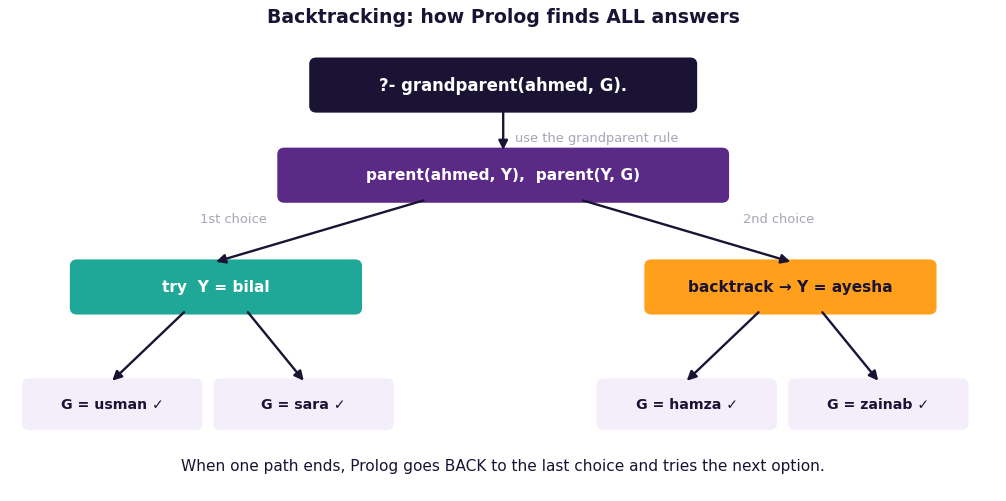

In [ ]:
#@title 📊 Visual explanation: how Prolog answers ?- grandparent(ahmed, G)
def fig_backtracking():
    fig, ax = plt.subplots(figsize=(12, 6))
    box(ax, 3.6, 5.0, 4.8, 0.7, "?- grandparent(ahmed, G).", fc=DARK, fs=14)
    box(ax, 3.2, 3.75, 5.6, 0.7, "parent(ahmed, Y),  parent(Y, G)", fc=PURPLE, fs=13)
    arrow(ax, 6, 5.0, 6, 4.45)
    ax.text(6.15, 4.62, "use the grandparent rule", fontsize=11, color=GREY, va="center")
    box(ax, 0.6, 2.2, 3.6, 0.7, "try  Y = bilal", fc=TEAL, fs=13)
    box(ax, 7.8, 2.2, 3.6, 0.7, "backtrack → Y = ayesha", fc=ORANGE, tc=DARK, fs=13)
    arrow(ax, 5, 3.75, 2.4, 2.9); arrow(ax, 7, 3.75, 9.6, 2.9)
    ax.text(2.2, 3.45, "1st choice", fontsize=11, color=GREY); ax.text(9.0, 3.45, "2nd choice", fontsize=11, color=GREY)
    res = [(0.0, "G = usman ✓"), (2.4, "G = sara ✓"), (7.2, "G = hamza ✓"), (9.6, "G = zainab ✓")]
    for x, t in res:
        box(ax, x, 0.6, 2.2, 0.65, t, fc=LIGHT, tc=DARK, fs=12)
    arrow(ax, 2.0, 2.2, 1.1, 1.25); arrow(ax, 2.8, 2.2, 3.5, 1.25)
    arrow(ax, 9.2, 2.2, 8.3, 1.25); arrow(ax, 10.0, 2.2, 10.7, 1.25)
    ax.text(6, 0.0, "When one path ends, Prolog goes BACK to the last choice and tries the next option.",
            ha="center", fontsize=13, color=DARK)
    ax.set_xlim(-0.2, 12.2); ax.set_ylim(-0.3, 5.9); ax.axis("off")
    finish(fig, "Backtracking: how Prolog finds ALL answers")
    return fig

fig_backtracking()
plt.show()

Prolog first tries **Y = bilal** and finds usman and sara. Then it **backtracks** (goes back) and tries **Y = ayesha**, finding hamza and zainab. Run the cell and check that you get all four.

In [ ]:
# ===== Using the RULES =====
ask("father(F, sara)", "family.pl")
ask("mother(M, hamza)", "family.pl")
ask("grandparent(ahmed, G)", "family.pl")   # watch backtracking give ALL grandchildren
ask("sibling(usman, S)", "family.pl")

---
## Part 4: Recursion — a rule that uses itself
An **ancestor** is a parent, OR a parent of an ancestor. The second rule calls `ancestor` again — that is **recursion**.

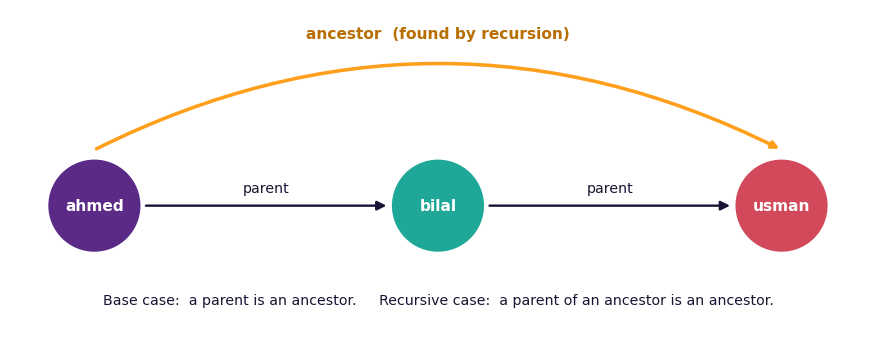

In [ ]:
#@title 📊 Visual explanation: the ancestor rule
def fig_ancestor_recursion():
    fig, ax = plt.subplots(figsize=(12, 4.2))
    people = ["ahmed", "bilal", "usman"]
    for i, p in enumerate(people):
        ax.add_patch(Circle((1 + i * 4, 1.6), 0.55, fc=[PURPLE, TEAL, ROSE][i], ec=WHITE, lw=2))
        ax.text(1 + i * 4, 1.6, p, ha="center", va="center", color=WHITE, fontsize=13, fontweight="bold")
    arrow(ax, 1.6, 1.6, 4.4, 1.6, text="parent", fs=12); arrow(ax, 5.6, 1.6, 8.4, 1.6, text="parent", fs=12)
    ax.annotate("", xy=(9, 2.25), xytext=(1, 2.25), arrowprops=dict(arrowstyle="-|>", color=ORANGE, lw=3,
                connectionstyle="arc3,rad=-0.25"))
    ax.text(5, 3.55, "ancestor  (found by recursion)", ha="center", fontsize=13, fontweight="bold", color="#B86E00")
    ax.text(5, 0.45, "Base case:  a parent is an ancestor.     Recursive case:  a parent of an ancestor is an ancestor.",
            ha="center", fontsize=12, color=DARK)
    ax.set_xlim(0, 10); ax.set_ylim(0.1, 3.9); ax.set_aspect("equal"); ax.axis("off")
    finish(fig)
    return fig

fig_ancestor_recursion()
plt.show()

In [ ]:
# ===== Recursion: ancestors =====
ask("ancestor(A, zainab)", "family.pl")
ask("ancestor(ahmed, D)", "family.pl")

---
## Part 5: Lists
A list is written in square brackets: `[ali, sara, usman]`. Prolog splits a list into a **Head** (first item) and a **Tail** (the rest) using `[H | T]`.

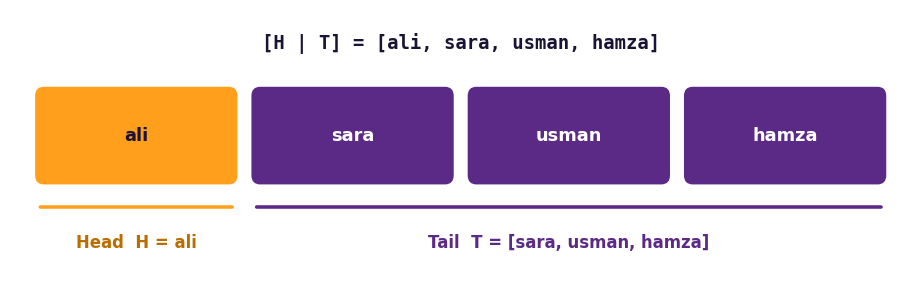

In [ ]:
#@title 📊 Visual explanation: Head and Tail of a list
def fig_list_head_tail():
    fig, ax = plt.subplots(figsize=(11, 3.6))
    items = ["ali", "sara", "usman", "hamza"]
    for i, it in enumerate(items):
        box(ax, 0.3 + i * 2.2, 1.0, 2.0, 0.9, it, fc=ORANGE if i == 0 else PURPLE, tc=DARK if i == 0 else WHITE, fs=15)
    ax.annotate("", xy=(0.3, 0.75), xytext=(2.3, 0.75), arrowprops=dict(arrowstyle="-", color=ORANGE, lw=3))
    ax.text(1.3, 0.35, "Head  H = ali", ha="center", fontsize=14, fontweight="bold", color="#B86E00")
    ax.annotate("", xy=(2.5, 0.75), xytext=(8.9, 0.75), arrowprops=dict(arrowstyle="-", color=PURPLE, lw=3))
    ax.text(5.7, 0.35, "Tail  T = [sara, usman, hamza]", ha="center", fontsize=14, fontweight="bold", color=PURPLE)
    ax.text(4.6, 2.3, "[H | T] = [ali, sara, usman, hamza]", ha="center", fontsize=16, fontweight="bold", color=DARK,
            family="monospace")
    ax.set_xlim(0, 9.2); ax.set_ylim(0, 2.7); ax.axis("off")
    finish(fig)
    return fig

fig_list_head_tail()
plt.show()

Most list rules have two parts:
1. **Base case** — the simplest list (usually the empty list `[]`)
2. **Recursive case** — do something with the Head, then call the rule again on the Tail

**Arithmetic** in Prolog uses `is`: `X is 2 + 3` gives `X = 5`.

In [ ]:
%%writefile lists.pl
% ----- Lists: [Head | Tail] -----
my_member(X, [X|_]).                          % X is the head          -> found
my_member(X, [_|Tail]) :- my_member(X, Tail).  % otherwise search the tail

my_length([], 0).                             % empty list has length 0
my_length([_|Tail], N) :- my_length(Tail, N1), N is N1 + 1.

my_sum([], 0).
my_sum([H|Tail], S) :- my_sum(Tail, S1), S is H + S1.

% ----- Arithmetic uses "is" -----
factorial(0, 1).
factorial(N, F) :- N > 0, N1 is N - 1, factorial(N1, F1), F is N * F1.

grade(Marks, 'A') :- Marks >= 85.
grade(Marks, 'B') :- Marks >= 70, Marks < 85.
grade(Marks, 'C') :- Marks >= 50, Marks < 70.
grade(Marks, 'F') :- Marks < 50.

In [ ]:
ask("[H|T] = [ali, sara, usman, hamza]", "lists.pl")
ask("my_member(usman, [ali, sara, usman])", "lists.pl")
ask("my_member(X, [red, green, blue])", "lists.pl")
ask("my_length([a, b, c, d], N)", "lists.pl")
ask("my_sum([10, 20, 30], S)", "lists.pl")

In [ ]:
ask("X is 7 * 6 + 2", "lists.pl")
ask("factorial(5, F)", "lists.pl")
ask("grade(78, G)", "lists.pl")
ask("grade(45, G)", "lists.pl")

---
## Part 6: A tiny expert system in Prolog
We give Prolog some **observations** about animals and some **rules from an expert**. Prolog then works out what each animal is. `\+` means **NOT**.

In [ ]:
%%writefile animals.pl
% ----- Observations (facts) -----
has(tweety, feathers).   can(tweety, fly).      lays(tweety, eggs).
has(tiger1, fur).        eats(tiger1, meat).    has(tiger1, stripes).
has(nemo, fins).         lives(nemo, water).
has(pingu, feathers).    lays(pingu, eggs).     lives(pingu, water).

% ----- Expert rules -----
class(X, bird)   :- has(X, feathers), lays(X, eggs).
class(X, mammal) :- has(X, fur).
class(X, fish)   :- has(X, fins), lives(X, water).

animal(X, tiger)   :- class(X, mammal), eats(X, meat), has(X, stripes).
animal(X, sparrow) :- class(X, bird), can(X, fly).
animal(X, penguin) :- class(X, bird), \+ can(X, fly), lives(X, water).   % \+ means NOT
animal(X, fish)    :- class(X, fish).

In [ ]:
ask("class(tweety, C)", "animals.pl")
ask("animal(pingu, T)", "animals.pl")
ask("animal(Name, Type)", "animals.pl")

---
## 📝 Lab Tasks
1. Add **your own family** (at least 3 generations) to `family.pl`. Ask 5 questions about it.
2. Write rules for `brother(X, Y)`, `sister(X, Y)`, `uncle(X, Y)` and `cousin(X, Y)`. Test them.
3. Write `my_max(List, Max)` that finds the largest number in a list.
4. Add two new animals and rules to `animals.pl` (e.g. *parrot*: bird that can fly and talks).
5. **Think:** why does `grandparent(ahmed, G)` give 4 answers? Explain using the word *backtracking*.